<a href="https://colab.research.google.com/github/orianadienta/Weather-based-Agricultural-Commodity-Price-Prediction/blob/main/Price_Prediction_Without_Weather_ML_C_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA**

## Missing Value Checking

In [ ]:
df = pd.read_csv('data_gabungan_agri_cuaca.csv')
print(df.isnull().sum())

tanggal                          0
suhu_max_c                       0
suhu_min_c                       0
suhu_mean_c                      0
curah_hujan_mm                   0
hujan_mm                         0
jam_hujan                        0
kecepatan_angin_max_kmh          0
kencang_angin_kmh                0
kelembapan_max_pct               0
kelembapan_min_pct               0
durasi_sinar_matahari_detik      0
kode_cuaca_wmo                   0
durasi_sinar_matahari_jam        0
Cabe/Lombok Keriting           326
Cabe/Lombok Merah Besar        326
Cabe/Lombok Rawit              326
Sayuran Bayam                  326
Sayuran Kacang Panjang         326
Sayuran Kangkung               326
Sayuran Sawi                   326
dtype: int64


##

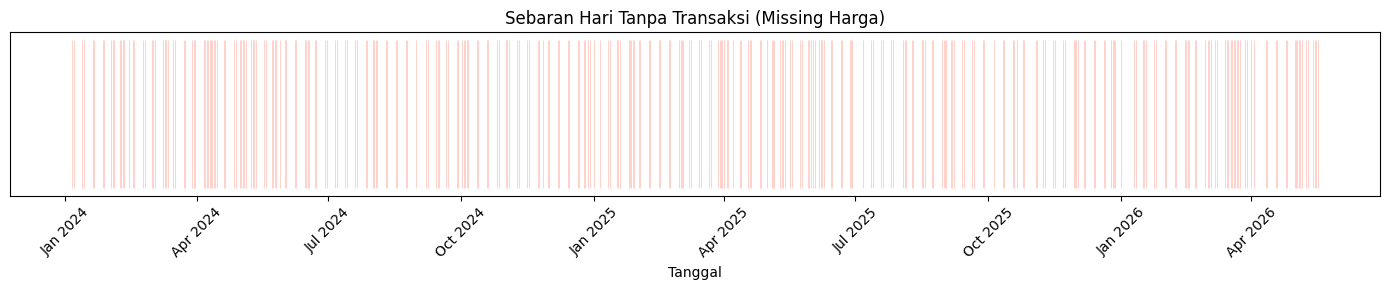

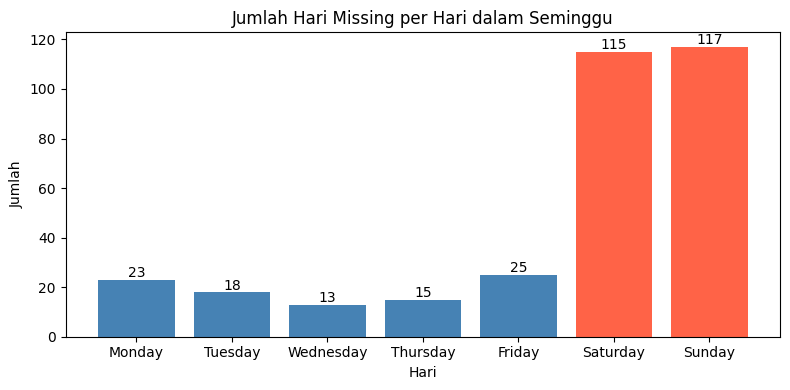

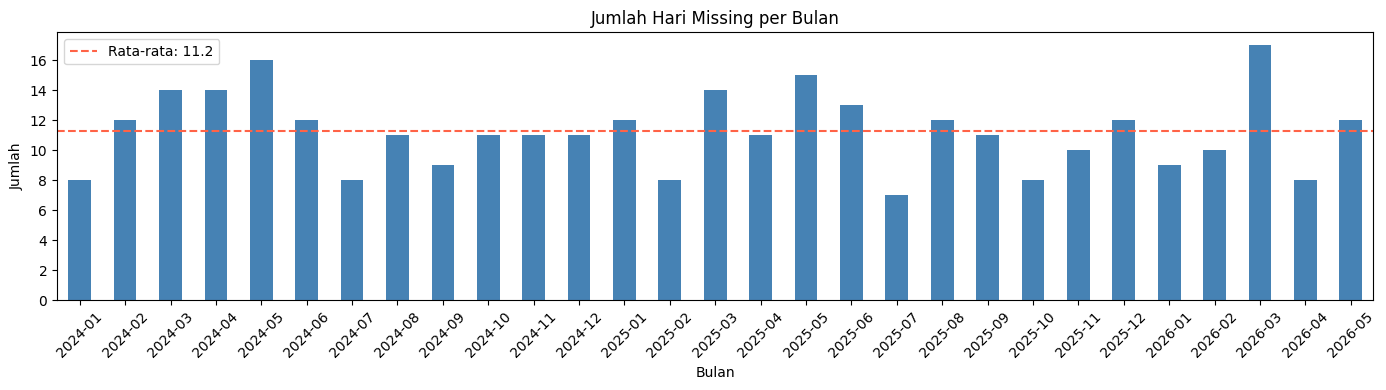

Total missing: 326 hari dari 872 hari (37.4%)

Missing per hari dalam seminggu:
nama_hari
Monday        23
Tuesday       18
Wednesday     13
Thursday      15
Friday        25
Saturday     115
Sunday       117


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('data_gabungan_agri_cuaca.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])

harga_cols = ['Cabe/Lombok Keriting', 'Cabe/Lombok Merah Besar', 'Cabe/Lombok Rawit',
              'Sayuran Bayam', 'Sayuran Kacang Panjang', 'Sayuran Kangkung', 'Sayuran Sawi']

# Missing value marking
df['is_missing'] = df[harga_cols[0]].isna()

# Distribution of missing value
fig, ax = plt.subplots(figsize=(14, 3))
missing_dates = df[df['is_missing']]['tanggal']
ax.vlines(missing_dates, 0, 1, color='tomato', alpha=0.4, linewidth=0.5)
ax.set_title('Distribution of Days Without Price Data')
ax.set_xlabel('Tanggal')
ax.set_yticks([])
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('missing_pattern_timeline.png', dpi=150)
plt.show()

# Missing per days
df['nama_hari'] = df['tanggal'].dt.day_name()
hari_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
missing_per_hari = df[df['is_missing']]['nama_hari'].value_counts().reindex(hari_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(missing_per_hari.index, missing_per_hari.values,
              color=['steelblue']*5 + ['tomato', 'tomato'])
ax.set_title('Jumlah Hari Missing per Hari dalam Seminggu')
ax.set_xlabel('Hari')
ax.set_ylabel('Jumlah')
for bar, val in zip(bars, missing_per_hari.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('missing_per_hari.png', dpi=150)
plt.show()

# Missing per month
df['bulan'] = df['tanggal'].dt.to_period('M')
missing_per_bulan = df[df['is_missing']].groupby('bulan').size()

fig, ax = plt.subplots(figsize=(14, 4))
missing_per_bulan.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Jumlah Hari Missing per Bulan')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah')
ax.axhline(y=missing_per_bulan.mean(), color='tomato', linestyle='--', label=f'Rata-rata: {missing_per_bulan.mean():.1f}')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('missing_per_bulan.png', dpi=150)
plt.show()

print(f"Total missing: {df['is_missing'].sum()} hari dari {len(df)} hari ({df['is_missing'].mean()*100:.1f}%)")
print(f"\nMissing per hari dalam seminggu:")
print(missing_per_hari.to_string())

# **Preprocessing**

## 1. Imputation

In [ ]:
import pandas as pd
df_merged = pd.read_csv('data_gabungan_agri_cuaca.csv')

# Imputation using forward fill
harga_cols = ['Cabe/Lombok Keriting', 'Cabe/Lombok Merah Besar', 'Cabe/Lombok Rawit',
              'Sayuran Bayam', 'Sayuran Kacang Panjang', 'Sayuran Kangkung', 'Sayuran Sawi']

df_merged[harga_cols] = df_merged[harga_cols].ffill()
df_merged.to_csv('data_gabungan_fix.csv', index=False)

In [ ]:
df.describe()

,suhu_max_c,suhu_min_c,suhu_mean_c,curah_hujan_mm,hujan_mm,jam_hujan,kecepatan_angin_max_kmh,kencang_angin_kmh,kelembapan_max_pct,kelembapan_min_pct,durasi_sinar_matahari_detik,kode_cuaca_wmo,durasi_sinar_matahari_jam,Cabe/Lombok Keriting,Cabe/Lombok Merah Besar,Cabe/Lombok Rawit,Sayuran Bayam,Sayuran Kacang Panjang,Sayuran Kangkung,Sayuran Sawi
count,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.00000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000
mean,29.769725,24.529931,26.908257,9.658945,9.658945,10.673165,12.81617,29.802408,96.331697,71.628305,32032.976365,58.846330,8.897959,54128.153670,53409.116972,59145.928899,9503.727064,10821.674312,8216.456422,11592.029817
std,1.229638,0.782595,0.762090,9.932428,9.932428,4.981234,2.79602,5.675579,3.208327,6.155356,10327.478483,8.716969,2.868687,14534.643927,13211.462816,20698.123235,3681.695247,3395.841543,2103.611064,3628.235854
min,25.500000,22.600000,24.200000,0.000000,0.000000,0.000000,7.00000,16.900000,78.780716,47.957360,0.000000,1.000000,0.000000,25000.000000,25000.000000,29000.000000,3000.000000,5000.000000,3000.000000,5000.000000
25%,29.000000,24.000000,26.400000,2.275000,2.275000,7.000000,10.90000,25.900000,95.045775,67.874822,26775.624500,53.000000,7.440000,43000.000000,43000.000000,40000.000000,7000.000000,10000.000000,6375.000000,10000.000000
50%,29.800000,24.500000,26.900000,6.900000,6.900000,10.000000,12.40000,29.200000,97.052060,72.024840,35692.244500,63.000000,9.915000,52000.000000,55000.000000,58000.000000,9000.000000,10000.000000,9000.000000,10000.000000
75%,30.500000,25.000000,27.500000,13.925000,13.925000,14.000000,14.20000,32.800000,98.232955,75.845810,39740.701250,63.000000,11.040000,62500.000000,62000.000000,73000.000000,11000.000000,12000.000000,10000.000000,12000.000000
max,33.200000,27.000000,28.800000,95.700000,95.700000,24.000000,25.00000,57.200000,100.000000,94.500300,43200.000000,65.000000,12.000000,97000.000000,90000.000000,122500.000000,26000.000000,25000.000000,12000.000000,26000.000000


## 2. Parsing Date Features and Feature Selection

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('Weather and price dataset.csv')
print(df.dtypes)

date                          object
max_temperature_c            float64
min_temperature_c            float64
mean_temperature_c           float64
rainfall_mm                  float64
precipitation_mm             float64
rain_duration_hours            int64
max_wind_speed_kmh           float64
wind_speed_kmh               float64
max_humidity_pct             float64
min_humidity_pct             float64
sunshine_duration_seconds    float64
wmo_weather_code               int64
sunshine_duration_hours      float64
Curly Chili Pepper             int64
Large Red Chili Pepper         int64
Bird's Eye Chili Pepper        int64
Spinach                        int64
Long Bean                      int64
Water Spinach                  int64
Mustard Greens                 int64
dtype: object


In [ ]:
# Parsing Date Feature
df['date'] = pd.to_datetime(df['date'])

df = df.set_index('date')
df = df.sort_index()

print(df.index.dtype)
print(df.head())

df = df.drop(columns=[
    'precipitation_mm',
    'sunshine_duration_seconds',
    'wmo_weather_code',
    'rain_duration_hours',
    'max_wind_speed_kmh',
    'max_temperature_c',
    'min_temperature_c',
    'mean_temperature_c',
    'rainfall_mm',
    'wind_speed_kmh',
    'max_humidity_pct',
    'min_humidity_pct',
    'sunshine_duration_hours',
])

print(df.shape)
print(df.columns.tolist())

df_raw = df.copy()
print(f"df_raw shape: {df_raw.shape}")
print(f"df_raw columns: {df_raw.columns.tolist()}")

datetime64[ns]
            max_temperature_c  min_temperature_c  mean_temperature_c  \
date                                                                   
2024-01-01               29.8               24.4                26.4   
2024-01-02               28.0               23.3                25.8   
2024-01-03               31.0               24.0                26.5   
2024-01-04               31.2               23.4                27.2   
2024-01-05               27.8               23.8                25.5   

            rainfall_mm  precipitation_mm  rain_duration_hours  \
date                                                             
2024-01-01          7.1               7.1                   12   
2024-01-02         16.1              16.1                   16   
2024-01-03          7.8               7.8                    9   
2024-01-04         13.3              13.3                   13   
2024-01-05         14.8              14.8                   19   

            max_w

# **Splitting the Dataset and Modeling Using N Loops**

In [ ]:
!pip install autogluon.tabular -q

import pandas as pd
import numpy as np



from xgboost import XGBRegressor
from autogluon.tabular import TabularPredictor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

price_cols = [
    'Curly Chili Pepper',
    'Large Red Chili Pepper',
    "Bird's Eye Chili Pepper",
    'Spinach',
    'Long Bean',
    'Water Spinach',
    'Mustard Greens',
]



all_xgb_results = []
all_ag_results  = []

for N in range(1, 8):   # N=1 s/d N=7
    print(f"\n{'='*60}")
    print(f"  N = {N}  (fitur H-1 sampai H-{N})")
    print(f"{'='*60}")

    # ── Feature engineering (selalu dari df_raw) ──────────────
    df = df_raw.copy()

    for col in price_cols:
        for n in range(1, N + 1):
            df[f'{col}_lag{n}'] = df[col].shift(n)


    target_cols = price_cols
    for col in target_cols:
        df[f'{col}_target_h1'] = df[col].shift(-1)

    df = df.dropna()

    # ── Split (dihitung ulang tiap N) ─────────────────────────
    split_idx = int(len(df) * 0.8)
    train = df.iloc[:split_idx].reset_index()
    test  = df.iloc[split_idx:].reset_index()

    target_h1_cols = [f'{c}_target_h1' for c in target_cols]

    feature_cols = [
        c for c in train.columns
        if c not in target_cols + target_h1_cols + ['date']
    ]

    print(f"Shape setelah dropna : {df.shape}")
    print(f"Train: {train['date'].min()} → {train['date'].max()} ({len(train)} baris)")
    print(f"Test : {test['date'].min()}  → {test['date'].max()}  ({len(test)} baris)")
    print(f"Jumlah fitur         : {len(feature_cols)}")

    # ── XGBoost ───────────────────────────────────────────────
    print(f"\n--- XGBoost N={N} ---")
    for target in target_cols:
        target_h1 = f'{target}_target_h1'

        model = XGBRegressor(random_state=42)
        model.fit(train[feature_cols], train[target_h1])
        y_pred = model.predict(test[feature_cols])
        y_test = test[target_h1]

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = mean_absolute_percentage_error(y_test, y_pred) * 100

        all_xgb_results.append({
            'N': N, 'Commodity': target,
            'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape,
        })
        print(f"  {target:30s}  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")

    # ── AutoGluon ─────────────────────────────────────────────
    print(f"\n--- AutoGluon N={N} ---")
    for target in target_cols:
        target_h1 = f'{target}_target_h1'

        cols_to_drop = (
            [c for c in target_h1_cols if c != target_h1]
            + target_cols
            + ['date']
        )
        train_input = train.drop(columns=cols_to_drop)
        test_input  = test.drop(columns=cols_to_drop)

        model_name = (
            target.replace("/", "_").replace(" ", "_").replace("'", "")
        )

        predictor = TabularPredictor(
            label=target_h1,
            path=f"models/N{N}_{model_name}_h1",   # ← N di path, nggak overwrite
            eval_metric="mean_absolute_error",
            problem_type="regression",
        )
        predictor.fit(train_input, time_limit=300, presets="medium_quality")

        y_pred = predictor.predict(test_input.drop(columns=[target_h1]))
        y_test = test_input[target_h1]

        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = mean_absolute_percentage_error(y_test, y_pred) * 100

        all_ag_results.append({
            'N': N, 'Commodity': target,
            'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape,
        })
        print(f"  {target:30s}  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")

xgb_results_df = pd.DataFrame(all_xgb_results)
ag_results_df  = pd.DataFrame(all_ag_results)
print("\n✅ Semua eksperimen selesai!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 9.9 MB/s eta 0:00:00

  N = 1  (fitur H-1 sampai H-1)
Shape setelah dropna : (870, 21)
Train: 2024-01-02 00:00:00 → 2025-11-27 00:00:00 (696 baris)
Test : 2025-11-28 00:00:00  → 2026-05-20 00:00:00  (174 baris)
Jumlah fitur         : 7

--- XGBoost N=1 ---
  Curly Chili Pepper              MAE=4487.56  RMSE=5965.19  MAPE=9.64%
  Large Red Chili Pepper          MAE=4853.23  RMSE=7338.77  MAPE=8.30%
  Bird's Eye Chili Pepper         MAE=13952.25  RMSE=18521.58 

Verbosity: 2 (Standard Logging)


  Water Spinach                   MAE=625.13  RMSE=834.72  MAPE=7.72%
  Mustard Greens                  MAE=856.04  RMSE=1067.17  MAPE=8.56%

--- AutoGluon N=1 ---


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       10.87 GB / 12.67 GB (85.7%)
Disk Space Avail:   65.47 GB / 112.64 GB (58.1%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/content/models/N1_Curly_Chili_Pepper_h1"
Train Data Rows:    696
Train Data Columns: 7
Label Column:       Curly Chili Pepper_target_h1
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available 

[1000]	valid_set's l1: 3829.6
[2000]	valid_set's l1: 3790.36
[3000]	valid_set's l1: 3772.18
[4000]	valid_set's l1: 3761.23
[5000]	valid_set's l1: 3748.21
[6000]	valid_set's l1: 3740.12
[7000]	valid_set's l1: 3734.66
[8000]	valid_set's l1: 3728.23
[9000]	valid_set's l1: 3723.57
[10000]	valid_set's l1: 3716.66


...

[1000]	valid_set's l1: 907.334


	-905.8919	 = Validation score   (-mean_absolute_error)
	1.57s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: RandomForestMSE ... Training model for up to 295.40s of the 295.40s of remaining time.
	Fitting with cpus=2, gpus=0
	-979.3498	 = Validation score   (-mean_absolute_error)
	2.18s	 = Training   runtime
	0.1s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 293.11s of the 293.11s of remaining time.
	Fitting with cpus=1, gpus=0
		`import catboost` failed. A quick tip is to install via `pip install autogluon.tabular[catboost]==1.5.0`.
Fitting model: ExtraTreesMSE ... Training model for up to 292.83s of the 292.83s of remaining time.
	Fitting with cpus=2, gpus=0
	-970.6223	 = Validation score   (-mean_absolute_error)
	0.88s	 = Training   runtime
	0.1s	 = Validation runtime
Fitting model: NeuralNetFastAI ... Training model for up to 291.84s of the 291.84s of remaining time.
	Fitting with cpus=1, gpus=0, mem=0.0/10.5 GB
	-1367.2536	 = Valid

[1000]	valid_set's l1: 974.284


	-974.283	 = Validation score   (-mean_absolute_error)
	3.57s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 299.91s of the 237.16s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/10.5 GB
	Ensemble Weights: {'NeuralNetTorch': 0.857, 'LightGBM': 0.071, 'XGBoost': 0.071}
	-758.4546	 = Validation score   (-mean_absolute_error)
	0.08s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 62.94s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 2416.3 rows/s (139 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/content/models/N7_Mustard_Greens_h1")


  Mustard Greens                  MAE=340.85  RMSE=453.26  MAPE=3.41%

✅ Semua eksperimen selesai!


# **Evaluation**


In [ ]:
# Rata-rata metrik per N
xgb_summary = xgb_results_df.groupby('N')[['MAE', 'RMSE', 'MAPE (%)']].mean().round(2)
ag_summary  = ag_results_df.groupby('N')[['MAE', 'RMSE', 'MAPE (%)']].mean().round(2)

print("=== XGBoost: rata-rata per N ===")
print(xgb_summary)

print("\n=== AutoGluon: rata-rata per N ===")
print(ag_summary)

# N terbaik berdasarkan RMSE rata-rata
best_xgb_N = xgb_summary['RMSE'].idxmin()
best_ag_N  = ag_summary['RMSE'].idxmin()

print(f"\n→ Best N XGBoost  : N={best_xgb_N}  (RMSE={xgb_summary.loc[best_xgb_N, 'RMSE']})")
print(f"→ Best N AutoGluon: N={best_ag_N}  (RMSE={ag_summary.loc[best_ag_N, 'RMSE']})")

=== XGBoost: rata-rata per N ===
       MAE     RMSE  MAPE (%)
N                            
1  3809.47  5121.42     10.40
2  4130.17  5910.97     11.54
3  3874.41  5717.05     10.28
4  2374.65  3366.45      7.90
5  2198.20  3089.49      6.79
6  2410.85  3209.38      6.80
7  2717.12  3540.69      8.74

=== AutoGluon: rata-rata per N ===
       MAE     RMSE  MAPE (%)
N                            
1  2173.62  3230.02      5.45
2  2288.48  3081.53      6.14
3  2901.48  4106.02      8.01
4  2003.16  2904.81      6.20
5  2892.70  3739.15      8.97
6  2270.60  3050.19      7.01
7  2929.83  3690.29      8.72

→ Best N XGBoost  : N=5  (RMSE=3089.49)
→ Best N AutoGluon: N=4  (RMSE=2904.81)


In [ ]:
short_names = {
    'Curly Chili Pepper': 'Curly Chili',
    'Large Red Chili Pepper': 'Large Red Chili',
    "Bird's Eye Chili Pepper": "Bird's Eye Chili",
    'Spinach': 'Spinach',
    'Long Bean': 'Long Bean',
    'Water Spinach': 'Water Spinach',
    'Mustard Greens': 'Mustard Greens'
}

metrics = ['MAE', 'RMSE', 'MAPE (%)']
col_names = [short_names[t] for t in price_cols] + ['Average']

for n in range(1, 8):
    rows = []
    idx = []

    xgb_n = xgb_results_df[xgb_results_df['N'] == n].set_index('Commodity')
    ag_n  = ag_results_df[ag_results_df['N'] == n].set_index('Commodity')

    for source_name, source_df in [('XGBoost', xgb_n), ('AutoGluon', ag_n)]:
        for met in metrics:
            row_vals = [round(source_df.loc[t, met], 2) for t in price_cols]
            avg = round(np.nanmean(row_vals), 2)
            rows.append(row_vals + [avg])
            idx.append((source_name, met))

    df_n = pd.DataFrame(
        rows,
        index=pd.MultiIndex.from_tuples(idx, names=['Model', 'Metric']),
        columns=col_names
    )

    display(
        df_n.style
        .background_gradient(cmap='RdYlGn_r', axis=1, subset=pd.IndexSlice[:, col_names])
        .format('{:,.2f}')
        .set_caption(f'N={n} (H-1 s/d H-{n}) — XGBoost vs AutoGluon')
        .set_table_styles([{
            'selector': 'caption',
            'props': [('font-weight', 'bold'), ('font-size', '13px'), ('margin-bottom', '8px')]
        }])
    )